In [3]:
import pandas as pd
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
from scipy.stats import wasserstein_distance
from matplotlib.pyplot import tight_layout

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

label_dict  = {}
label_dict['huber_value'] = r"Huber $\mathcal{H}$"
label_dict['stem_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Stem, max}$"
label_dict['stem_hydraulic_capacitance_res'] = r"$\Gamma_\mathrm{Stem_res}$"
label_dict['leaf_hydraulic_capacitance'] = r"$\Gamma_\mathrm{Leaf}$"
label_dict['g0'] = r"$g_0$"
label_dict['g1'] = r"$g_1$"
label_dict['k_xylem_sat'] = r"$K_\mathrm{xyl, max}$"
label_dict['psi50_xylem'] = r"$\psi_{50}$"
label_dict['psi88_xylem'] = r"$\psi_{88}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['pore_0'] = r"$\xi$"
label_dict['jackson_root_beta'] = r"$\mathrm{Root}_\beta$"
label_dict['psi_leaf_50_close'] = r"$\psi_{Leaf, close}$"
label_dict['d_50_close'] = r"$d_{Leaf, close}$"
label_dict['alpha'] = r"$\alpha$"
label_dict['gam_stem_x_H'] = r"$\Gamma_\mathrm{Stem} \cdot \mathcal{H}$"
label_dict['gam_stem_div_g0'] = r"$\frac{g_0}{\Gamma_\mathrm{Stem}}$"
label_dict['k_xyl_x_H'] = r"$K_\mathrm{xyl, max}\cdot \mathcal{H}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"
label_dict['g_min_loss'] = r"$g_0 + g_\mathrm{Bark}$"
label_dict['wcont_sigma_deviation'] = r"$\sigma_\mathrm{wcont}$"
label_dict['p50-p88'] =  r"$\psi_{50} - \psi_{88} $"
label_dict['g0_div_gam_stem_x_H'] =  r"g0_div_gam_stem_x_H"
label_dict['g0_div_gam_stem_x_H'] =  r"g0_div_gam_stem_x_H"
label_dict['k_soil_sat0'] =  r"k_soil_sat"
label_dict['root_area_index'] =  r"RAI"
label_dict['psi_tlp'] = r'$\psi_\mathrm{tlp}$'



unit_dict= {}
unit_dict['stem_hydraulic_capacitance'] = "kg m-3 MPa-1"
unit_dict['stem_hydraulic_capacitance_res'] = "kg m-3 MPa-1"
unit_dict['leaf_hydraulic_capacitance'] = "kg m-2 MPa-1"
unit_dict['k_xylem_sat'] = "kg m-1 s-1 MPa-1"
unit_dict['huber_value'] = "cm2 m-2"
unit_dict['psi50_xylem'] = "MPa"
unit_dict['psi88_xylem'] = "MPa"
unit_dict['g0'] = "mol m-1 s-1"
unit_dict['g1'] = "-"
unit_dict['g_stem_res'] = "mol m-1 s-1"
unit_dict['psi_leaf_50_close'] = r"MPa"
unit_dict['d_50_close'] = "-"
unit_dict['alpha'] = r"-"
unit_dict['gam_stem_x_H'] = r"-"
unit_dict['gam_stem_div_g0'] = r"-"
unit_dict['k_xyl_x_H'] =r"-"
unit_dict['g_min_loss'] = r"-"
unit_dict['wcont_sigma_deviation'] = r"-"
unit_dict['p50-p88'] =  "MPa"
unit_dict['psi_tlp'] =  "MPa"
unit_dict['g0_div_gam_stem_x_H'] =  "-"
unit_dict['pore_0'] =  "-"
unit_dict['k_soil_sat0'] =  "m s-1"
unit_dict['root_area_index'] =  "m2 m-2"


root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "45_LHS_TLP"
nmax = 1000
#scenario_name = "23_ex_con_2025_full_logit_mean_one_wcont"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
vars_all = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
        'leaf_hydraulic_capacitance', 'psi50_xylem', 'psi88_xylem', 'g0', 'k_soil_sat0', 'psi_soil_sat0', 'jackson_root_beta',
        'pore_0', 'root_area_index', 'wcont_sigma_deviation', 'alpha', 'g_stem_res','gam_stem_x_H','k_xyl_x_H', 
        'g0_div_gam_stem_x_H', 'g_min_loss', 'p50-p88', 'g1', 'psi_tlp']

vars_all.append('stem_hydraulic_capacitance_res')

vars_plant = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close', 'alpha','psi88_xylem']

vars_plant_ex = ['stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value', 'leaf_hydraulic_capacitance', 'psi50_xylem',
              'g0','psi_leaf_50_close', 'd_50_close', 'alpha','psi88_xylem', 'gam_stem_x_H','k_xyl_x_H', 'g0_div_gam_stem_x_H', 'g_min_loss']
vars_all_ex = vars_all.copy()
vars_all_ex.append("RMSE_MAX")

df = pd.read_csv(os.path.join(post_path, f"All_RMSE_{nmax}.csv"))
df['stem_hydraulic_capacitance'] *= 18.0/1000.0
df['stem_hydraulic_capacitance_res'] *= 18.0/1000.0
df['huber_value'] *= 10000.0
df['k_xylem_sat'] *= 18.0/1000.0
df['alpha'] = df['g_stem_res']/ df['g0']
df['gam_stem_x_H'] = df['stem_hydraulic_capacitance'] * df['huber_value']
df['k_xyl_x_H'] = df['k_xylem_sat'] * df['huber_value']
df['g0_div_gam_stem_x_H'] =  df['g0']/df['stem_hydraulic_capacitance']* df['huber_value']
df['g_min_loss'] = df['g0'] + df['g_stem_res']
df['p50-p88'] = df['psi50_xylem'] - df['psi88_xylem']


df.loc[df['sid'] ==0, 'sid'] =1 
df.loc[df['sid'] ==-1, 'sid'] =0 
df.loc[df['sid'] ==3, 'sid'] =2 
df.loc[df['sid'] ==6, 'sid'] =3 
df.loc[df['sid'] ==7, 'sid'] =4 

index_to_drop = df[(df['sid']==2)|(df['sid']==2)].index
df.drop(index_to_drop, inplace=True)

dv = df[vars_all]
dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
df_norm = dv
df_norm['sid'] = df['sid']

df_norm.shape



df_norm['alive'] = 1
df_norm.loc[df_norm['sid'] > 0, 'alive'] = 0

df_norm["sid_group"] = df_norm["sid"].apply(lambda s: "sid 0" if s == 0 else "other")
palette = {"sid 0": "tab:blue", "other": "tab:red"}

/tmp/ipykernel_873610/2767618411.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dv['leaf_hydraulic_capacitance'] = np.log10(dv['leaf_hydraulic_capacitance'])
/tmp/ipykernel_873610/2767618411.py:128: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_norm['sid'] = df['sid']
/tmp/ipykernel_873610/2767618411.py:134: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

In [16]:
# Multiple variables
vars_to_compare = [
    "stem_hydraulic_capacitance", "g0"
    # add more variables here, e.g. "xylem_conductivity", "leaf_area_index"
]
vars_to_compare = ['psi_leaf_50_close',
 #'d_50_close',
 'stem_hydraulic_capacitance',
 'stem_hydraulic_capacitance_res',
 'k_xylem_sat',
 'huber_value',
 'leaf_hydraulic_capacitance',
 #'psi50_xylem',
 'psi88_xylem',
 'p50-p88',
 'g0',
 #'jackson_root_beta',

 #'root_area_index',
 'wcont_sigma_deviation',
 'alpha',
 #'g_stem_res',
 #'#gam_stem_x_H',
 #'k_xyl_x_H',
 #'g0_div_gam_stem_x_H',
 #'g_min_loss',
 
 'g1', 'psi_tlp' ]

['k_soil_sat0',
 'psi_soil_sat0', 'pore_0',]



['k_soil_sat0', 'psi_soil_sat0', 'pore_0']

In [17]:
df_norm

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,psi88_xylem,g0,k_soil_sat0,...,k_xyl_x_H,g0_div_gam_stem_x_H,g_min_loss,p50-p88,g1,psi_tlp,stem_hydraulic_capacitance_res,sid,alive,sid_group
0,-1.170655,30.561303,155.226221,1.327310,5.527894,0.169385,-4.174568,-5.294621,0.001470,0.000002,...,7.337227,0.000052,0.001526,1.120053,2.643890,-2.246219,29.806627,1,0,other
1,-1.029523,32.788055,178.295664,1.813305,4.784758,0.215825,-3.912420,-5.003773,0.001491,0.000002,...,8.676224,0.000040,0.001770,1.091354,2.467178,-2.313786,28.605303,1,0,other
2,-1.084725,53.420413,143.835330,1.532250,5.618517,0.221829,-4.164752,-5.021926,0.001453,0.000002,...,8.608971,0.000057,0.001797,0.857173,2.346005,-2.499411,27.708120,1,0,other
3,-1.109167,34.257899,179.758919,1.774551,5.673470,0.126633,-4.002529,-5.048493,0.001502,0.000002,...,10.067862,0.000047,0.001606,1.045964,2.109832,-1.939658,29.597464,1,0,other
4,-1.158427,31.379560,158.262084,1.866757,5.695305,0.216792,-4.125658,-4.737779,0.001570,0.000002,...,10.631748,0.000056,0.001689,0.612121,2.382212,-2.370760,29.772954,1,0,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.175538,12.499833,167.780709,0.782958,5.282112,-0.385814,-3.984602,-4.807302,0.001597,0.000002,...,4.135671,0.000050,0.001793,0.822700,1.785285,-2.199197,17.253510,0,1,sid 0
4996,-1.193110,8.819479,184.187682,1.084175,5.420108,-0.086254,-4.007522,-4.745391,0.001516,0.000002,...,5.876345,0.000045,0.001948,0.737869,2.293681,-2.182417,26.449630,0,1,sid 0
4997,-1.148675,29.304127,149.793894,0.776142,5.955417,-0.302060,-3.505040,-4.322135,0.001568,0.000002,...,4.622247,0.000062,0.001764,0.817095,2.046576,-2.008621,16.751452,0,1,sid 0
4998,-1.199217,12.419833,199.819626,1.332122,5.158369,-0.180279,-3.925566,-4.996599,0.001547,0.000002,...,6.871579,0.000040,0.001692,1.071034,2.676573,-2.379440,24.219943,0,1,sid 0


In [18]:
[ label_dict[l] for l in vars_to_compare]

['$\\psi_{Leaf, close}$',
 '$\\Gamma_\\mathrm{Stem, max}$',
 '$\\Gamma_\\mathrm{Stem_res}$',
 '$K_\\mathrm{xyl, max}$',
 'Huber $\\mathcal{H}$',
 '$\\Gamma_\\mathrm{Leaf}$',
 '$\\psi_{88}$',
 '$\\psi_{50} - \\psi_{88} $',
 '$g_0$',
 '$\\sigma_\\mathrm{wcont}$',
 '$\\alpha$',
 '$g_1$',
 '$\\psi_\\mathrm{tlp}$']

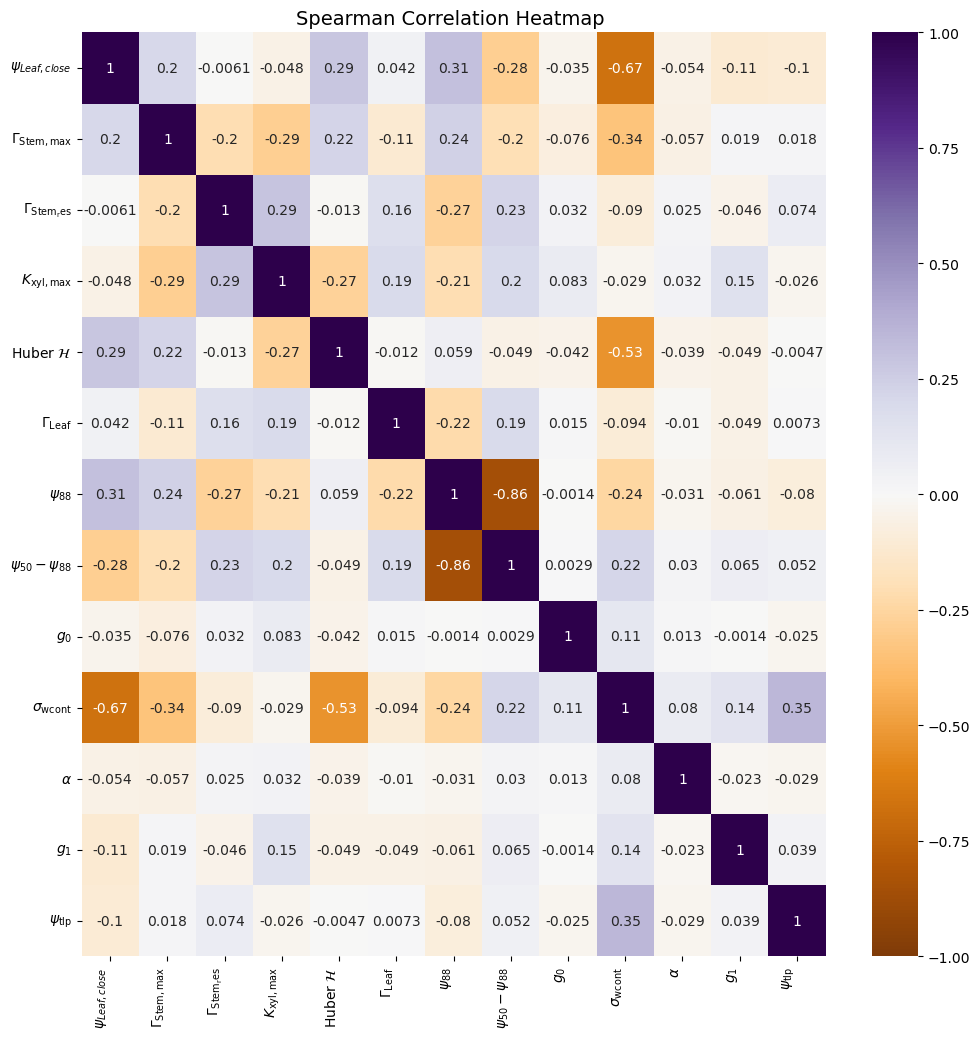

In [19]:
corr = df_norm[vars_to_compare].corr(method='spearman')
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, cmap='PuOr', vmin=-1, vmax=1,    xticklabels=[ label_dict[l] for l in vars_to_compare],   # custom x-axis labels
    yticklabels=[ label_dict[l] for l in vars_to_compare]);
plt.title(f'Spearman Correlation Heatmap ', fontsize=14);
plt.xticks(rotation=90, ha='right') 
plt.yticks(rotation=00, ha='right') 
plt.savefig(os.path.join(post_path, f"corr_.png"))

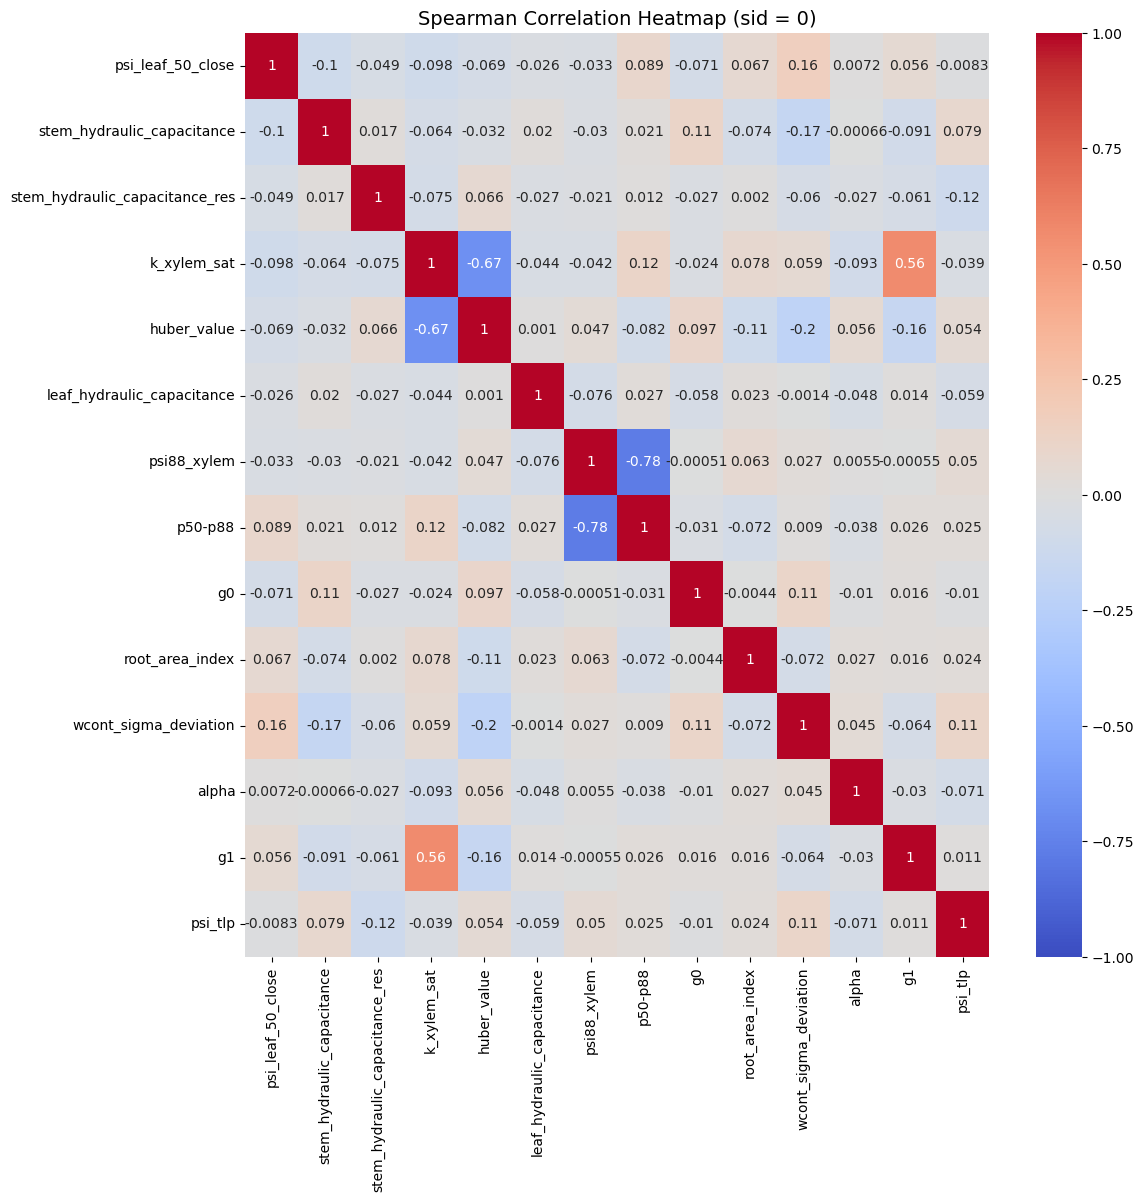

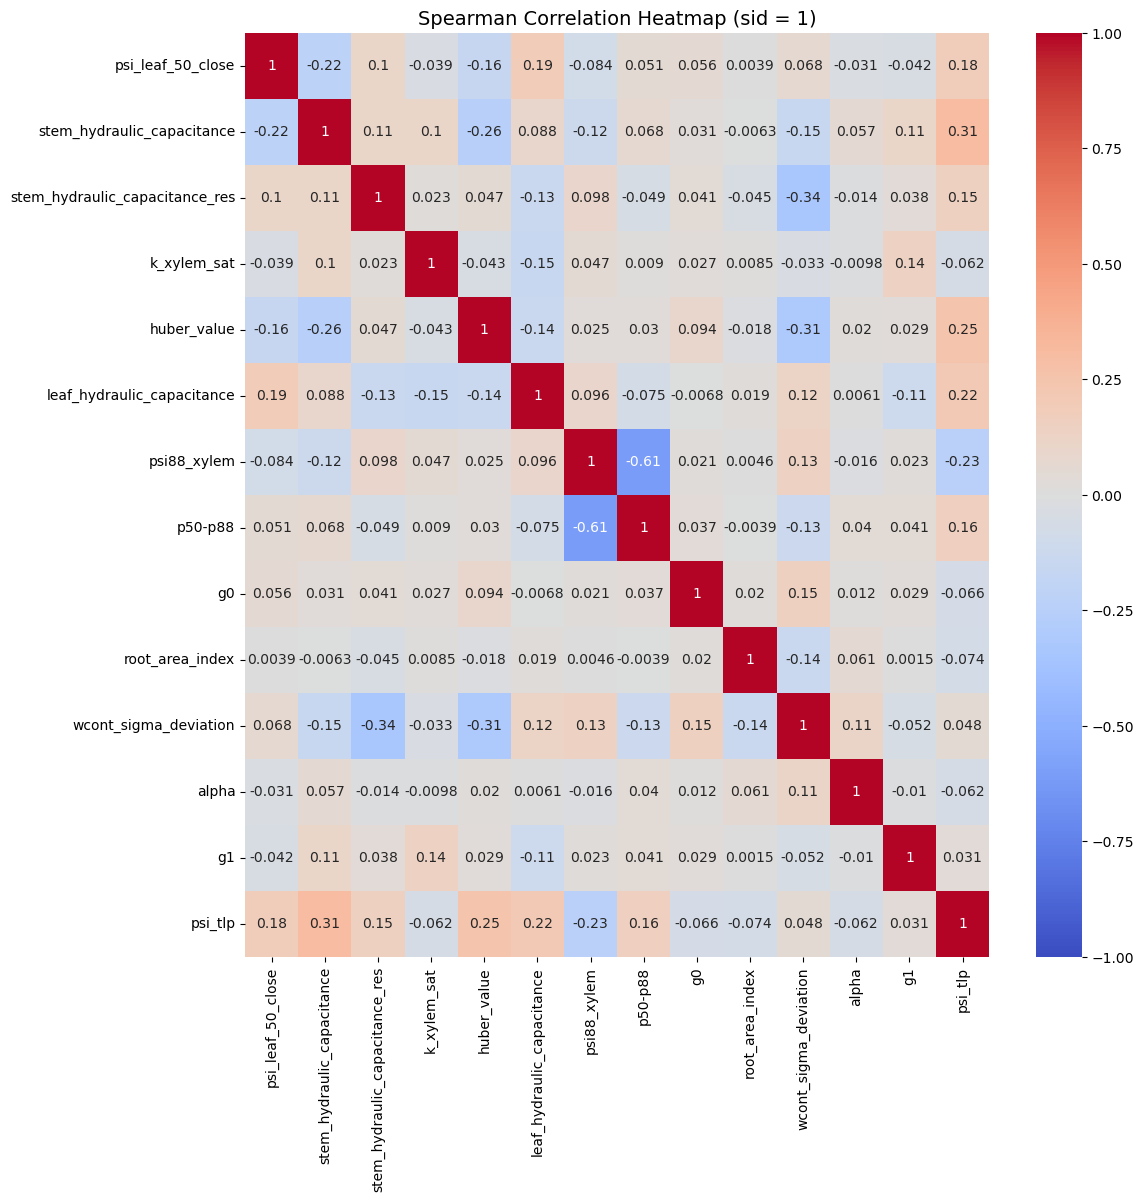

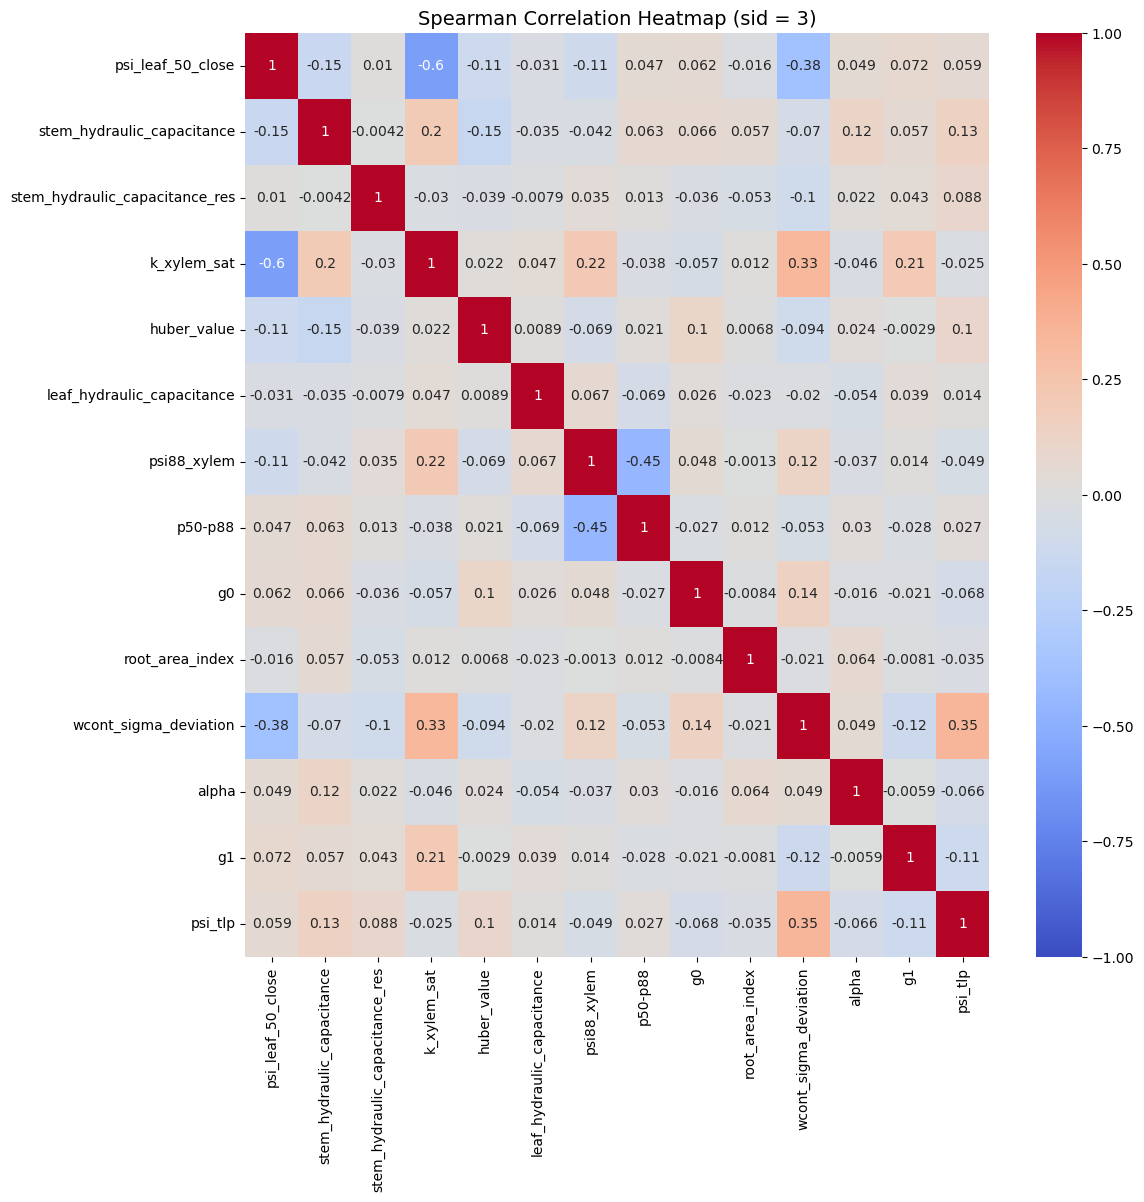

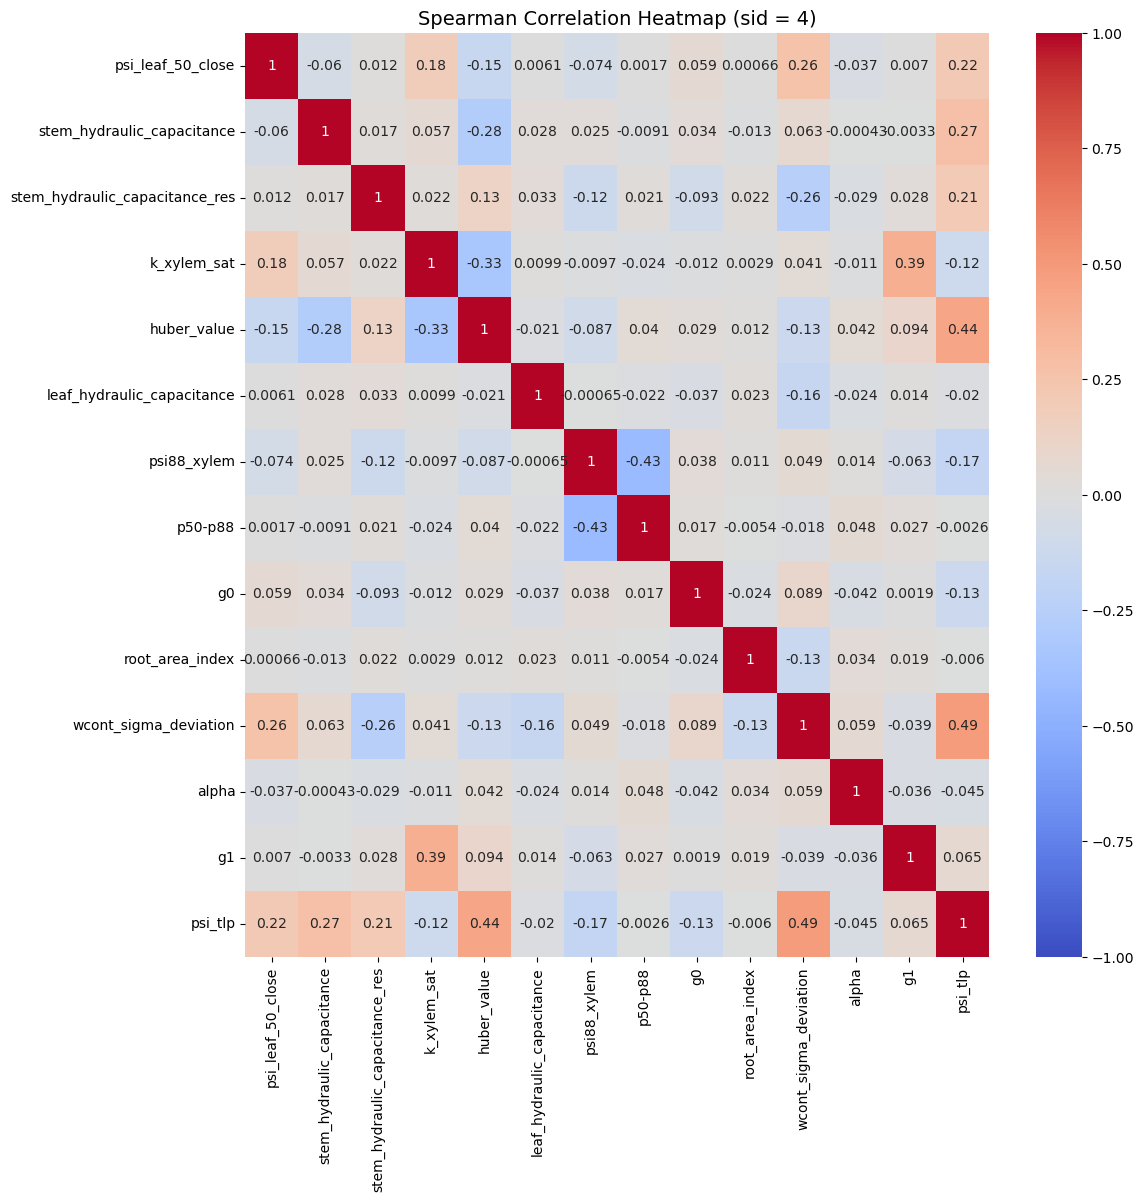

In [12]:
# Loop over each sid value
for sid_val in sorted(df_norm['sid'].unique()):
    subset = df_norm[df_norm['sid'] == sid_val]
    corr = subset[vars_to_compare].corr(method='spearman')

    plt.figure(figsize=(12, 12))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1);
    plt.title(f'Spearman Correlation Heatmap (sid = {sid_val})', fontsize=14);
    plt.savefig(os.path.join(post_path, f"corr_{sid_val}.png"));

In [14]:
import numpy as np
import pandas as pd

corr_threshold = 0.4
correlations_by_sid = {}

for sid_val in sorted(df_norm['sid'].unique()):
    subset = df_norm[df_norm['sid'] == sid_val]
    subset = df_norm
    corr = subset[vars_to_compare].corr(method='spearman')

    # Flatten correlation matrix (keep only upper triangle, no self-correlations)
    corr_long = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
    )
    corr_long.columns = ['var1', 'var2', 'r']
    corr_long['abs_r'] = corr_long['r'].abs()
    corr_long['r_squared'] = corr_long['r'] ** 2

    # Filter by absolute correlation threshold
    filtered = corr_long[corr_long['abs_r'] > corr_threshold].sort_values(
        'abs_r', ascending=False
    )

    correlations_by_sid[sid_val] = filtered

# 🧾 Print results nicely
for sid_val, df_corr in correlations_by_sid.items():
    print(f"\n=== SID {sid_val} ===")
    if df_corr.empty:
        print("No correlations above threshold.")
    else:
        for _, row in df_corr.iterrows():
            print(f"{row.var1} — {row.var2}: r = {row.r:.3f}, r² = {row.r_squared:.3f}")



=== SID 0 ===
psi88_xylem — p50-p88: r = -0.859, r² = 0.738
psi_leaf_50_close — wcont_sigma_deviation: r = -0.673, r² = 0.453
huber_value — wcont_sigma_deviation: r = -0.533, r² = 0.284

=== SID 1 ===
psi88_xylem — p50-p88: r = -0.859, r² = 0.738
psi_leaf_50_close — wcont_sigma_deviation: r = -0.673, r² = 0.453
huber_value — wcont_sigma_deviation: r = -0.533, r² = 0.284

=== SID 3 ===
psi88_xylem — p50-p88: r = -0.859, r² = 0.738
psi_leaf_50_close — wcont_sigma_deviation: r = -0.673, r² = 0.453
huber_value — wcont_sigma_deviation: r = -0.533, r² = 0.284

=== SID 4 ===
psi88_xylem — p50-p88: r = -0.859, r² = 0.738
psi_leaf_50_close — wcont_sigma_deviation: r = -0.673, r² = 0.453
huber_value — wcont_sigma_deviation: r = -0.533, r² = 0.284


In [6]:
df_dead = df_norm[df_norm['alive'] ==0]

      psi_leaf_50_close  d_50_close  stem_hydraulic_capacitance  k_xylem_sat  \
0             -1.170655   30.561303                  155.226221     1.327310   
1             -1.029523   32.788055                  178.295664     1.813305   
2             -1.084725   53.420413                  143.835330     1.532250   
3             -1.109167   34.257899                  179.758919     1.774551   
4             -1.158427   31.379560                  158.262084     1.866757   
...                 ...         ...                         ...          ...   
4995          -1.175538   12.499833                  167.780709     0.782958   
4996          -1.193110    8.819479                  184.187682     1.084175   
4997          -1.148675   29.304127                  149.793894     0.776142   
4998          -1.199217   12.419833                  199.819626     1.332122   
4999          -1.189456    3.873731                  184.599474     1.153877   

      huber_value  leaf_hydraulic_capac

,Principal Component,Explained Variance (%)
0,PC1,90.28
1,PC2,8.90
2,PC3,0.37



=== PCA Loadings ===


,PC1,PC2,PC3
psi_leaf_50_close,0.003,0.000,-0.018
stem_hydraulic_capacitance,0.997,0.073,0.004
stem_hydraulic_capacitance_res,-0.074,0.997,0.013
k_xylem_sat,-0.006,0.015,-0.007
huber_value,0.005,0.004,-0.054
leaf_hydraulic_capacitance,-0.001,0.005,-0.005
psi88_xylem,0.005,-0.017,-0.007
p50-p88,-0.003,0.010,0.005
g0,-0.000,0.000,0.000
root_area_index,-0.000,-0.011,0.991


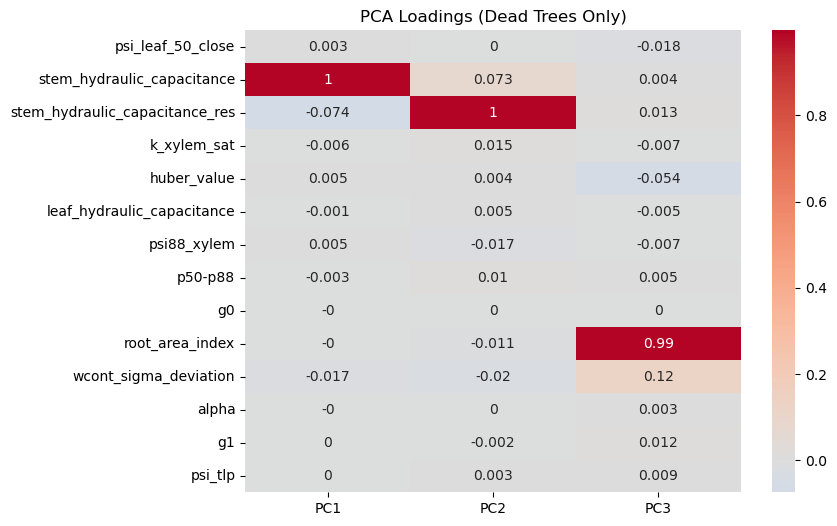


Top variables in PC1:
stem_hydraulic_capacitance        0.997
stem_hydraulic_capacitance_res    0.074
wcont_sigma_deviation             0.017
k_xylem_sat                       0.006
psi88_xylem                       0.005
Name: PC1, dtype: float64

Top variables in PC2:
stem_hydraulic_capacitance_res    0.997
stem_hydraulic_capacitance        0.073
wcont_sigma_deviation             0.020
psi88_xylem                       0.017
k_xylem_sat                       0.015
Name: PC2, dtype: float64

Top variables in PC3:
root_area_index                   0.991
wcont_sigma_deviation             0.121
huber_value                       0.054
psi_leaf_50_close                 0.018
stem_hydraulic_capacitance_res    0.013
Name: PC3, dtype: float64


In [7]:

from sklearn.feature_selection import mutual_info_regression
import pandas as pd

df_dead = df_norm
print(df_dead)

features = vars_to_compare

from sklearn.decomposition import PCA

pca = PCA(n_components=3).fit(df_norm[vars_to_compare])

# ---- 1) Variance Explained Table ----
explained_var = pd.DataFrame({
    "Principal Component": ["PC1", "PC2", "PC3"],
    "Explained Variance (%)": (pca.explained_variance_ratio_ * 100).round(2)
})
print("\n=== Explained Variance ===")
display(explained_var)

# ---- 2) PCA Loadings Table ----
loadings = pd.DataFrame(
    pca.components_.T,
    index=vars_to_compare,
    columns=["PC1", "PC2", "PC3"]
).round(3)

print("\n=== PCA Loadings ===")
display(loadings)

# ---- 3) Heatmap for Clean Visualization ----
plt.figure(figsize=(8,6))
sns.heatmap(loadings, cmap="coolwarm", center=0, annot=True)
plt.title("PCA Loadings (Dead Trees Only)")
plt.show()

# ---- 4) Optionally show top contributors per PC ----
for pc in ["PC1","PC2","PC3"]:
    print(f"\nTop variables in {pc}:")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))

In [17]:
df_dead[vars_to_compare]

,psi_leaf_50_close,stem_hydraulic_capacitance,stem_hydraulic_capacitance_res,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi88_xylem,p50-p88,g0,root_area_index,wcont_sigma_deviation,alpha,g1,psi_tlp
0,-1.170655,155.226221,29.806627,1.327310,5.527894,0.169385,-5.294621,1.120053,0.001470,10.986390,0.286513,0.037833,2.643890,-2.246219
1,-1.029523,178.295664,28.605303,1.813305,4.784758,0.215825,-5.003773,1.091354,0.001491,8.059814,0.648836,0.186863,2.467178,-2.313786
2,-1.084725,143.835330,27.708120,1.532250,5.618517,0.221829,-5.021926,0.857173,0.001453,8.646205,0.418156,0.236815,2.346005,-2.499411
3,-1.109167,179.758919,29.597464,1.774551,5.673470,0.126633,-5.048493,1.045964,0.001502,10.817726,0.407489,0.068964,2.109832,-1.939658
4,-1.158427,158.262084,29.772954,1.866757,5.695305,0.216792,-4.737779,0.612121,0.001570,9.525546,0.435950,0.075840,2.382212,-2.370760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,-0.839009,153.426729,28.454778,1.928204,5.508804,-0.009661,-4.108610,0.553260,0.001558,9.325246,1.230992,0.217555,2.241609,-1.753916
3996,-0.966331,144.158407,27.608645,1.479707,5.733125,-0.425987,-4.281829,0.763606,0.001418,10.154336,1.085770,0.284101,2.312586,-1.932857
3997,-0.995154,144.679525,29.235097,1.032276,5.879724,-0.207359,-4.356217,0.759915,0.001444,9.882773,1.195985,0.290835,2.088095,-1.784575
3998,-1.170769,194.270146,19.600720,1.774971,4.197156,-0.483379,-4.045104,0.364253,0.001432,9.513048,0.453609,0.066121,2.416388,-2.420842
